In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
data = pd.read_csv('Titanic-Dataset.csv')

#view first few rows
print("First 5 rows of our data:")
data.head()

First 5 rows of our data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Basic information:")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

Basic information:
Rows: 891, Columns: 12

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:
#missing data
print("Missing values in each column:")
missing = data.isnull().sum()
print(missing[missing > 0])

Missing values in each column:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [8]:
#fill missing ages with the median age
data['Age'].fillna(data['Age'].median(), inplace=True)
print("Fixed missing Age values")

Fixed missing Age values


In [9]:
#Fill with most common port
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
print("Fixed missing Embarked values")

Fixed missing Embarked values


In [10]:
#dropping unnecessary columns
data = data.drop(['PassengerId', 'Cabin', 'Ticket', 'Name'], axis=1)
print("Removed unhelpful columns")

Removed unhelpful columns


In [11]:
#Create family size
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['Alone'] = (data['FamilySize'] == 1).astype(int)
print("Created FamilySize and Alone features")

Created FamilySize and Alone features


In [12]:
#Convert text to numbers
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

#Convert Sex to numbers (male=1, female=0)
data['Sex'] = encoder.fit_transform(data['Sex'])

#Convert Embarked to numbers
data['Embarked'] = encoder.fit_transform(data['Embarked'])

print("Converted text columns to numbers")
print(f"Sex values now: {sorted(data['Sex'].unique())}")
print(f"Embarked values now: {sorted(data['Embarked'].unique())}")

Converted text columns to numbers
Sex values now: [np.int64(0), np.int64(1)]
Embarked values now: [np.int64(0), np.int64(1), np.int64(2)]


In [13]:
#See our cleaned data
print("Our cleaned data:")
print(f"Shape: {data.shape}")
print("\nFirst 5 rows:")
data.head()

Our cleaned data:
Shape: (891, 10)

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Alone
0,0,3,1,22.0,1,0,7.2500,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,0
2,1,3,0,26.0,0,0,7.9250,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0
4,0,3,1,35.0,0,0,8.0500,2,1,1


In [14]:
#survival rate
survival_rate = data['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")
print(f"Survived: {data['Survived'].sum()}, Did not survive: {len(data) - data['Survived'].sum()}")

Overall survival rate: 38.4%
Survived: 342, Did not survive: 549


In [15]:
#Separate features (X) and target (y)
X = data.drop('Survived', axis=1)  # Features
y = data['Survived']  # Target (what we want to predict)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (891, 9)
Target shape: (891,)


In [16]:
#Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 712
Testing set size: 179


In [17]:
#Train a simple model
from sklearn.ensemble import RandomForestClassifier

#Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train model
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [19]:
#Make predictions
#Predict on test set
y_pred = model.predict(X_test)

print("Made predictions on test set")
print(f"Sample predictions: {y_pred[:10]}")
print(f"Actual values: {y_test.values[:10]}")

Made predictions on test set
Sample predictions: [0 0 0 1 0 1 1 0 1 1]
Actual values: [1 0 0 1 1 1 1 0 1 1]


In [20]:
#accuracy check
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.2%}")

Model accuracy: 81.56%


In [21]:
#Better evaluation
from sklearn.metrics import classification_report

print("Detailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

Detailed Performance Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.85       105
       Survived       0.79      0.76      0.77        74

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.81      0.82      0.82       179



Most important features for predicting survival:
      feature  importance
1         Sex    0.281250
5        Fare    0.255096
2         Age    0.246047
0      Pclass    0.086759
7  FamilySize    0.044755
6    Embarked    0.031321
3       SibSp    0.026913
4       Parch    0.019532
8       Alone    0.008327


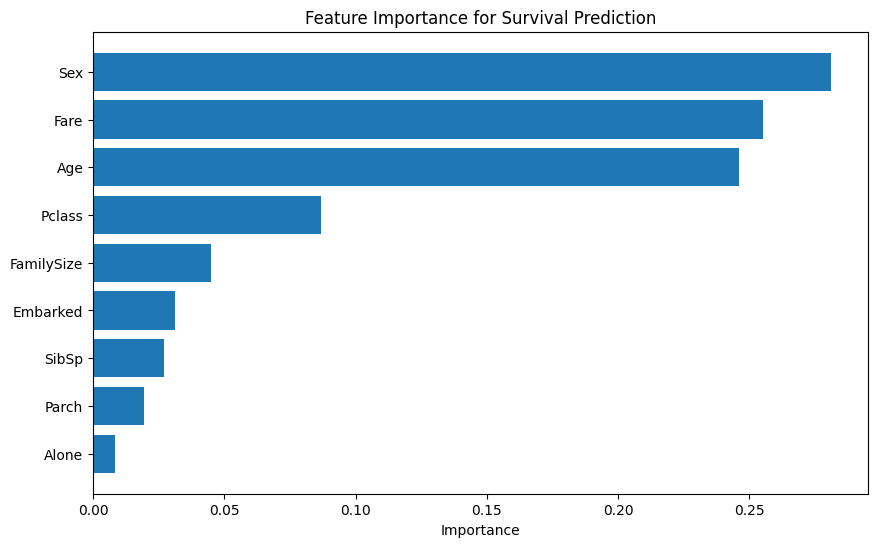

In [22]:
#See what features are important
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Most important features for predicting survival:")
print(feature_importance)

#Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Survival Prediction')
plt.gca().invert_yaxis()  # Most important at top
plt.show()

In [23]:
#predictions for new passengers
#Create sample new passengers
new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2],
    'Sex': [0, 1, 0],  # 0=female, 1=male
    'Age': [25, 30, 17],
    'SibSp': [0, 1, 2],
    'Parch': [0, 0, 1],
    'Fare': [100.0, 7.5, 25.0],
    'Embarked': [0, 1, 2],  # C=0, Q=1, S=2
    'FamilySize': [1, 2, 4],
    'Alone': [1, 0, 0]
})

#Make predictions
new_predictions = model.predict(new_passengers)
new_probabilities = model.predict_proba(new_passengers)

print("Predictions for new passengers:")
for i, (pred, prob) in enumerate(zip(new_predictions, new_probabilities)):
    status = "Would survive" if pred == 1 else "Would not survive"
    survival_chance = prob[1] * 100
    print(f"Passenger {i+1}: {status} ({survival_chance:.1f}% chance)")

Predictions for new passengers:
Passenger 1: Would survive (99.0% chance)
Passenger 2: Would not survive (14.0% chance)
Passenger 3: Would survive (91.0% chance)
